# Transjakarta Peak-Hour Congestion Analysis

## Project Overview

Transjakarta is Jakarta's Bus Rapid Transit system. This project analyzes tap-in/tap-out transaction data to answer one central question:

**Where and when is Transjakarta most congested, and which corridors should be prioritized for additional fleet allocation during peak hours?**

To answer this, the analysis looks at:
- Overall ridership volume by time of day
- Trip duration during peak versus non-peak hours, and whether the difference is statistically meaningful
- Which specific corridors are most affected

**Stakeholder:** Transjakarta operations and fleet planning team.

**Data Source:** Transjakarta tap-in/tap-out transaction records for April 2023, containing 37,900 trips across 221 corridors.

**Tools Used:** Python (pandas, numpy, matplotlib, seaborn, scipy) in Jupyter Notebook via VS Code.

**Scope:** This analysis covers a single month of transaction data and focuses only on time-of-day and corridor-level congestion patterns. It does not include fleet capacity data, dispatch schedules, or fare/revenue analysis, those are out of scope for this question.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)

In [2]:
plt.rcParams["font.family"] = "Noto Serif"
plt.rcParams["figure.facecolor"] = "#191919"
plt.rcParams["figure.edgecolor"] = "#191919"
plt.rcParams["axes.facecolor"] = "#191919"
plt.rcParams["savefig.facecolor"] = "#191919"
plt.rcParams["savefig.edgecolor"] = "#191919"
plt.rcParams["text.color"] = "#FAFAFA"
plt.rcParams["axes.labelcolor"] = "#FAFAFA"
plt.rcParams["axes.titlecolor"] = "#FAFAFA"
plt.rcParams["axes.edgecolor"] = "#FAFAFA"
plt.rcParams["xtick.color"] = "#FAFAFA"
plt.rcParams["ytick.color"] = "#FAFAFA"

ACCENT = "#8F002F"
DIM = "#4B4B4B"

## Data Understanding and Cleaning

In [3]:
df = pd.read_csv("../data/raw/dfTransjakarta.csv")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 37,900
Columns: 22


,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,Pal Putih,-6.184631,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,Kemenkes 2,-6.228700,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,Gg. Kunir II,-6.133132,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,Taman Elok 1,-6.195743,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,Sunter Boulevard Barat,-6.149650,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0


### Selecting Relevant Columns

This analysis focuses on when and where congestion happens, not who is riding. Rider-level fields (`payCardBank`, `payCardName`, `payCardSex`, `payCardBirthDate`) and `payAmount` are out of scope for this question and are dropped here.

In [4]:
relevant_cols = [
    "transID", "corridorID", "corridorName", "direction",
    "tapInStopsName", "tapInStopsLat", "tapInStopsLon", "stopStartSeq",
    "tapInTime", "tapOutStopsName", "tapOutTime", "stopEndSeq"
]
df = df[relevant_cols]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transID          37900 non-null  str    
 1   corridorID       36643 non-null  str    
 2   corridorName     35970 non-null  str    
 3   direction        37900 non-null  float64
 4   tapInStopsName   37900 non-null  str    
 5   tapInStopsLat    37900 non-null  float64
 6   tapInStopsLon    37900 non-null  float64
 7   stopStartSeq     37900 non-null  int64  
 8   tapInTime        37900 non-null  str    
 9   tapOutStopsName  36556 non-null  str    
 10  tapOutTime       36556 non-null  str    
 11  stopEndSeq       36556 non-null  float64
dtypes: float64(4), int64(1), str(7)
memory usage: 3.5 MB


In [5]:
df["tapInTime"] = pd.to_datetime(df["tapInTime"], errors="coerce")
df["tapOutTime"] = pd.to_datetime(df["tapOutTime"], errors="coerce")

print("Duplicate transID rows:", df["transID"].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Duplicate transID rows: 0
Fully duplicate rows: 0


### Data Quality Findings

- No duplicate transaction IDs or fully duplicate rows were found.
- `tapOutTime` (and the related `tapOutStopsName`/`stopEndSeq`) is missing on 1,344 rows (3.5%), trips with no recorded exit.
- `corridorID`/`corridorName` is missing on up to 1,930 rows (5.1%), trips that can't be attributed to a route.
- These two missing-value groups are largely independent (only 52 rows overlap both), so rows are not dropped outright. Two working subsets are built instead: `df_hourly`, the full dataset for overall time-of-day patterns (only needs `tapInTime`), and `df_duration`, a filtered subset for anything requiring trip duration or corridor grouping.

In [6]:
df_hourly = df.dropna(subset=["tapInTime"]).copy()

df_duration = df.dropna(subset=["tapOutTime", "corridorID"]).copy()

print(f"Full dataset for hourly patterns: {len(df_hourly):,} rows")
print(f"Subset for duration/corridor analysis: {len(df_duration):,} rows "
      f"({len(df_duration) / len(df) * 100:.1f}% of total)")

Full dataset for hourly patterns: 37,900 rows
Subset for duration/corridor analysis: 35,351 rows (93.3% of total)


### Feature Engineering

Three columns are derived from `tapInTime`: hour of day, day of week, and a peak-hour flag. The peak-hour flag is data-driven rather than assumption-based: it flags the top third of hours (8 of 24) ranked by transaction volume, rather than a fixed clock window since the actual hourly volume did not cleanly match a standard 6-9am/4-7pm rush-hour assumption.

In [7]:
for d in [df_hourly, df_duration]:
    d["hour_of_day"] = d["tapInTime"].dt.hour
    d["day_of_week"] = d["tapInTime"].dt.day_name()

hourly_counts = (
    df_hourly.groupby("hour_of_day").size()
    .reindex(range(24), fill_value=0)
    .sort_values(ascending=False)
)
n_peak_hours = 24 // 3
peak_hours = set(hourly_counts.head(n_peak_hours).index)

print("Peak hours (data-driven, top third):", sorted(peak_hours))

for d in [df_hourly, df_duration]:
    d["is_peak_hour"] = d["hour_of_day"].isin(peak_hours)

df_hourly[["hour_of_day", "day_of_week", "is_peak_hour"]].head()

Peak hours (data-driven, top third): [5, 6, 7, 8, 9, 16, 17, 19]


,hour_of_day,day_of_week,is_peak_hour
0,5,Monday,True
1,5,Monday,True
2,5,Monday,True
3,5,Monday,True
4,6,Monday,True


In [8]:
df_duration["trip_duration_minutes"] = (
    (df_duration["tapOutTime"] - df_duration["tapInTime"]).dt.total_seconds() / 60
)

df_duration["trip_duration_minutes"].describe()

count    35351.000000
mean        72.169082
std         28.059825
min         15.000000
25%         51.150000
50%         71.933333
75%         95.766667
max        179.050000
Name: trip_duration_minutes, dtype: float64

The cleaned and feature-engineered dataset is saved as a checkpoint before moving into analysis.

In [9]:
df_duration.to_csv("../data/processed/transjakarta_congestion_cleaned.csv", index=False)
print("Saved:", df_duration.shape)

Saved: (35351, 16)


## Data Analysis

### 1. Hourly Transaction Volume

Is there a clear peak-hour pattern in when people tap in?

In [10]:
hourly_volume = df_hourly.groupby("hour_of_day").size().reset_index(name="transaction_count")

colors = [ACCENT if is_peak else DIM
          for is_peak in df_hourly.groupby("hour_of_day")["is_peak_hour"].first()]

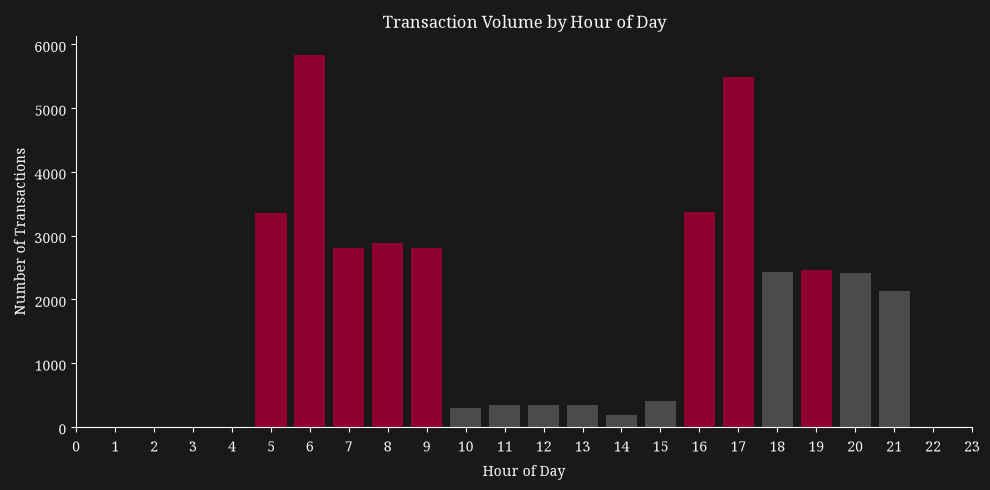

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(hourly_volume["hour_of_day"], hourly_volume["transaction_count"], color=colors)
plt.title("Transaction Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(0, 24))
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../images/hourly_transaction_volume.png", dpi=150)
plt.show()

**Findings:** Transaction volume is heavily concentrated in a small part of the day. The 8 peak hours identified (5-9am and 16, 17, 19) account for roughly 29,000 of the 37,900 total transactions, about 76.5% of all ridership, despite being only a third of the 24-hour day. The single busiest hour is 6am (5,839 transactions, 15.4% of daily volume), closely followed by 5pm (5,488, 14.5%). This concentration suggests fleet capacity planned for an average hour would be significantly under-provisioned during these specific windows.

### 2. Trip Duration, Peak vs Non-Peak Hours

Do peak-hour trips actually take longer than non-peak trips, and is the difference statistically meaningful or just random variation?

In [12]:
peak_durations = df_duration.loc[df_duration["is_peak_hour"], "trip_duration_minutes"]
nonpeak_durations = df_duration.loc[~df_duration["is_peak_hour"], "trip_duration_minutes"]

print(f"Peak hours:     mean = {peak_durations.mean():.1f} min, n = {len(peak_durations):,}")
print(f"Non-peak hours: mean = {nonpeak_durations.mean():.1f} min, n = {len(nonpeak_durations):,}")

t_stat, p_value = stats.ttest_ind(peak_durations, nonpeak_durations, equal_var=False)
print(f"\nt-statistic = {t_stat:.2f}, p-value = {p_value:.5f}")

Peak hours:     mean = 69.4 min, n = 27,036
Non-peak hours: mean = 81.2 min, n = 8,315

t-statistic = -36.90, p-value = 0.00000


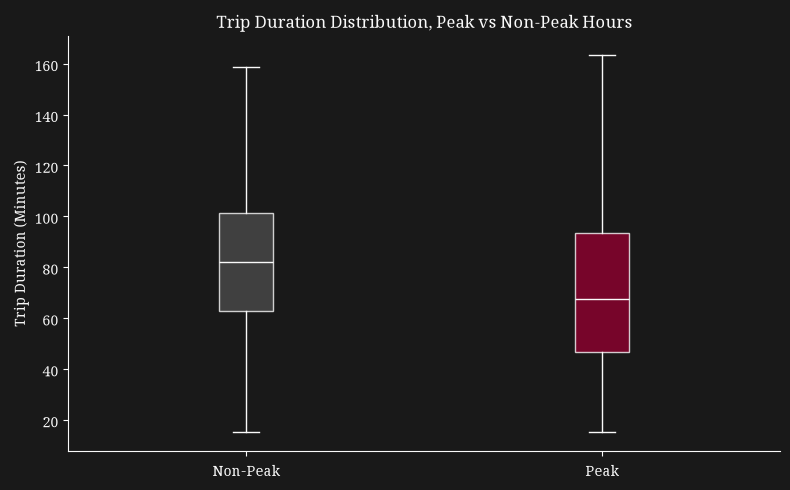

In [13]:
plt.figure(figsize=(8, 5))
box_data = [nonpeak_durations, peak_durations]
colors_box = [DIM, ACCENT]

bp = plt.boxplot(
    box_data, tick_labels=["Non-Peak", "Peak"], patch_artist=True, showfliers=False,
    whiskerprops=dict(color="#FAFAFA"),
    capprops=dict(color="#FAFAFA"),
    medianprops=dict(color="#FAFAFA"),
)

for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_edgecolor("#FAFAFA")
    patch.set_alpha(0.8)

plt.title("Trip Duration Distribution, Peak vs Non-Peak Hours")
plt.ylabel("Trip Duration (Minutes)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../images/duration_peak_vs_nonpeak.png", dpi=150)
plt.show()

Before interpreting the duration difference, check whether peak and non-peak trips differ in the number of stops traveled, since a shorter average distance alone could produce a shorter average duration regardless of congestion or service frequency.

In [14]:
df_duration["stops_traveled"] = df_duration["stopEndSeq"] - df_duration["stopStartSeq"]
df_duration["min_per_stop"] = (
    df_duration["trip_duration_minutes"] / df_duration["stops_traveled"].replace(0, np.nan)
)

comparison = df_duration.groupby("is_peak_hour")[
    ["stops_traveled", "trip_duration_minutes", "min_per_stop"]
].mean()
comparison

,stops_traveled,trip_duration_minutes,min_per_stop
is_peak_hour,,,
False,7.918701,81.207001,28.346251
True,7.569611,69.389444,24.583123


**Findings:** Contrary to the initial hypothesis, peak-hour trips are statistically significantly *shorter* than off-peak trips (69.4 vs 81.2 minutes, Welch's t-test, p < 0.00001), not longer. This holds even after controlling for trip distance, peak-hour trips cover a similar number of stops (7.57 vs 7.92), yet average 24.6 minutes per stop versus 28.3 minutes per stop off-peak. A likely explanation is that Transjakarta already runs higher-frequency service during known peak windows, reducing wait time between tap-in and boarding, while off-peak service (lower frequency) results in longer waits baked into the tap-in-to-tap-out duration.

**Limitation:** `trip_duration_minutes` measures tap-in to tap-out elapsed time, a mix of wait time and in-vehicle travel time that can't be separated with this data. This metric cannot confirm or rule out in-vehicle crowding during peak hours, it only shows that current peak-hour service moves passengers through the system efficiently relative to off-peak. The volume concentration from Chart 1 remains a separate, valid signal about peak-hour demand and potential crowding that duration alone can't speak to.

### 3. Peak-Hour Load by Corridor

Which specific corridors carry the most peak-hour transaction volume, and should be prioritized for additional fleet allocation?

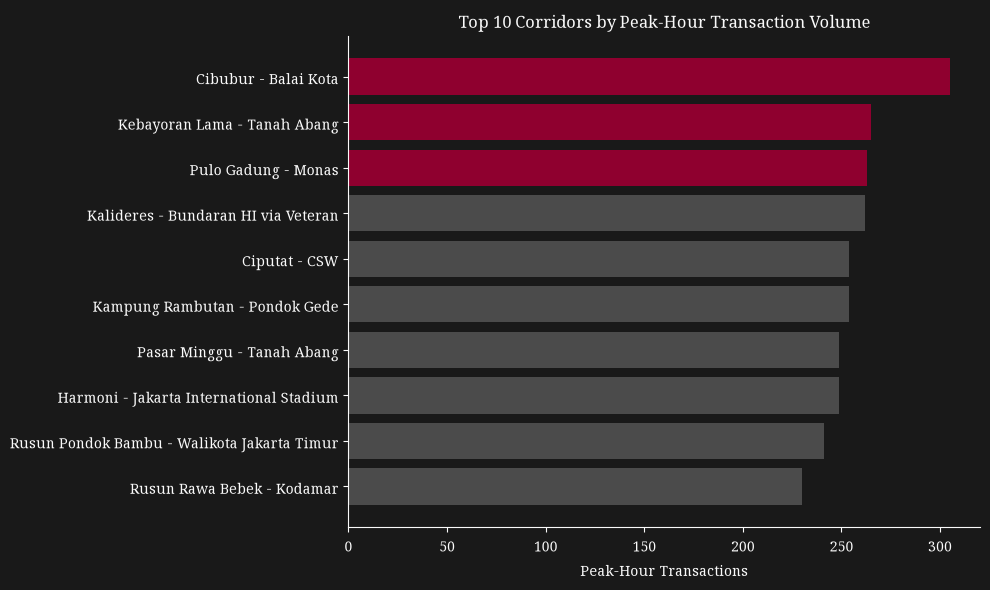

In [15]:
peak_corridor_volume = (
    df_duration[df_duration["is_peak_hour"]]
    .groupby("corridorName")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

colors = [ACCENT if i < 3 else DIM for i in range(len(peak_corridor_volume))]

plt.figure(figsize=(10, 6))
plt.barh(peak_corridor_volume.index[::-1], peak_corridor_volume.values[::-1],
          color=colors[::-1])
plt.title("Top 10 Corridors by Peak-Hour Transaction Volume")
plt.xlabel("Peak-Hour Transactions")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../images/top_corridors_peak_volume.png", dpi=150)
plt.show()

**Findings:** Peak-hour transactions are spread across 216 distinct corridors, and the top 10 are fairly close together (230 to 305 transactions each), no single corridor dominates. Cibubur - Balai Kota leads at 305 peak-hour transactions, followed by Kebayoran Lama - Tanah Abang (265) and Pulo Gadung - Monas (263). However, these top 3 corridors together account for only 3.1% of total peak-hour volume (27,036 trips), meaning corridor-level concentration is much weaker than the time-of-day concentration found in Chart 1. Prioritizing these specific corridors would address a real but narrow slice of peak-hour demand, not the bulk of it.

## Conclusions and Recommendations

1. **Prioritize time-based fleet scheduling over corridor-based reallocation.** 76.5% of ridership is concentrated in 8 hours of the day (5-9am, 16-17, 19), while peak-hour transaction volume is spread thinly across 216 corridors with no strong concentration (top 3 corridors account for only 3.1% of peak volume). Scheduling more buses system-wide during these 8 hours is better supported by the data than targeting a small list of corridors.

2. **Investigate off-peak service frequency, not peak-hour congestion.** Peak-hour trips are significantly *faster* per stop (24.6 min/stop) than off-peak trips (28.3 min/stop), even after controlling for distance traveled. This suggests off-peak service, not peak-hour service, may be the bigger operational gap, likely due to lower bus frequency increasing wait time between tap-in and boarding.

3. **Treat peak-hour crowding as a separate, still-open question.** Trip duration data confirms peak hours move passengers efficiently, but cannot confirm or rule out in-vehicle crowding, since duration mixes wait time and travel time. A follow-up analysis with vehicle capacity or passenger count data would be needed to assess crowding directly.

**Limitations:** This analysis covers a single month (April 2023) and does not include fleet size, dispatch schedules, or vehicle capacity data. The `is_peak_hour` flag was derived from this dataset's own volume distribution rather than an official schedule, so it may not exactly match Transjakarta's internal operational definitions of rush hour.